In [38]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
cur_path = '.'
data_path = 'data'
train_file_name = 'train.csv'
test_file_name = 'test.csv'
submission_file_name = 'sample_submission.csv'

In [45]:
submission = pd.read_csv(os.path.join(cur_path, data_path, submission_file_name),encoding='utf-8')
train_raw = pd.read_csv(os.path.join(cur_path, data_path, train_file_name), encoding='utf-8')
test_raw = pd.read_csv(os.path.join(cur_path, data_path, test_file_name), encoding='utf-8')

In [3]:
train_raw

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년),가격(백만원)
0,TRAIN_0000,P사,TayGTS,Nearly New,86.077,AWD,13642,0,No,2,159.66
1,TRAIN_0001,K사,Niro,Nearly New,56.000,FWD,10199,6,No,0,28.01
2,TRAIN_0002,A사,eT,Brand New,91.200,AWD,2361,7,No,0,66.27
3,TRAIN_0003,A사,RSeTGT,Nearly New,NaN,AWD,21683,3,No,0,99.16
4,TRAIN_0004,B사,i5,Pre-Owned,61.018,AWD,178205,1,No,0,62.02
...,...,...,...,...,...,...,...,...,...,...,...
7492,TRAIN_7492,H사,ION5,Brand New,NaN,AWD,3773,10,No,0,35.95
7493,TRAIN_7493,B사,i3,Pre-Owned,46.000,RWD,135411,2,No,0,23.40
7494,TRAIN_7494,P사,TayCT,Brand New,NaN,AWD,1363,2,No,0,120.00
7495,TRAIN_7495,B사,i3,Nearly New,56.000,RWD,39445,6,No,2,24.00


In [4]:
train_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
배터리용량,4786.0,69.397187,15.283635,46.0,56.359,68.125,78.227,99.80
주행거리(km),7497.0,44287.979458,55204.064386,3.0,5465.000,17331.000,61252.000,199827.00
보증기간(년),7497.0,4.960918,3.155342,0.0,2.000,5.000,8.000,10.00
연식(년),7497.0,0.222489,0.569232,0.0,0.000,0.000,0.000,2.00
가격(백만원),7497.0,62.331949,36.646759,9.0,34.390,56.000,80.050,161.09


In [5]:
test_raw

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년)
0,TEST_000,P사,TayCT,Nearly New,76.093,AWD,14057,2,No,0
1,TEST_001,B사,iX,Brand New,90.000,AWD,7547,8,No,0
2,TEST_002,B사,i5,Brand New,NaN,RWD,7197,7,Yes,0
3,TEST_003,H사,ION5,Nearly New,68.479,AWD,10357,7,No,1
4,TEST_004,K사,EV6,Brand New,NaN,FWD,7597,10,No,0
...,...,...,...,...,...,...,...,...,...,...
841,TEST_841,P사,TayGTS,Pre-Owned,64.683,AWD,117298,2,No,0
842,TEST_842,V사,ID4,Pre-Owned,55.547,AWD,72308,0,No,0
843,TEST_843,V사,ID4,Pre-Owned,55.547,AWD,124537,0,No,0
844,TEST_844,A사,Q4eT,Nearly New,69.646,AWD,15629,4,No,0


In [6]:
train_raw.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7497 entries, 0 to 7496
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7497 non-null   object 
 1   제조사       7497 non-null   object 
 2   모델        7497 non-null   object 
 3   차량상태      7497 non-null   object 
 4   배터리용량     4786 non-null   float64
 5   구동방식      7497 non-null   object 
 6   주행거리(km)  7497 non-null   int64  
 7   보증기간(년)   7497 non-null   int64  
 8   사고이력      7497 non-null   object 
 9   연식(년)     7497 non-null   int64  
 10  가격(백만원)   7497 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 644.4+ KB


In [7]:
train_raw.isna().sum() # 결측치 확인

ID             0
제조사            0
모델             0
차량상태           0
배터리용량       2711
구동방식           0
주행거리(km)       0
보증기간(년)        0
사고이력           0
연식(년)          0
가격(백만원)        0
dtype: int64

In [9]:
train_raw.corr(numeric_only=True).T

,배터리용량,주행거리(km),보증기간(년),연식(년),가격(백만원)
배터리용량,1.000000,-0.576538,0.558242,-0.021845,0.431668
주행거리(km),-0.576538,1.000000,-0.664071,-0.089586,-0.035488
보증기간(년),0.558242,-0.664071,1.000000,0.035294,-0.349962
연식(년),-0.021845,-0.089586,0.035294,1.000000,-0.058455
가격(백만원),0.431668,-0.035488,-0.349962,-0.058455,1.000000


# Data Preprocessing

### Column '배터리용량' - 결측치 존재O 
- 연속형 변수
- 결측치 처리
    - 차량상태 별 평균으로 채우기

### Column '주행거리(km)' 
- 연속형 변수
- 분포에 outlier가 많이 보이므로 구간별로 나누는 방법 사용

### Column '모델'
- 명목형 변수 (One - Hot Encoding)
- 모델 개수 파악 후 상위 5개 이외는 나머지로 분류

### Column 차량상태
- 주행거리가 큰 의미를 가지므로 사용X

### Column 보증기간(년)

### Column 사고이력
- 명목형 변수 (One - Hot Encoding)

### 연식(년)
- 명목형 변수(One - Hot Encoding)
- 값이 3개

In [10]:
train_raw.groupby(by = '차량상태').mean(numeric_only=True)[['배터리용량']].index

Index(['Brand New', 'Nearly New', 'Pre-Owned'], dtype='object', name='차량상태')

In [43]:
train_raw.groupby('차량상태')['배터리용량'].transform('mean')

0       66.678888
1       66.678888
2       92.586567
3       66.678888
4       59.053240
          ...    
7492    92.586567
7493    59.053240
7494    92.586567
7495    66.678888
7496    59.053240
Name: 배터리용량, Length: 7497, dtype: float64

In [41]:
train_raw['배터리용량'] = train_raw['배터리용량'].fillna(
    train_raw.groupby('차량상태')['배터리용량'].transform('mean')
)

In [42]:
train_raw

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년),가격(백만원)
0,TRAIN_0000,P사,TayGTS,Nearly New,86.077000,AWD,13642,0,No,2,159.66
1,TRAIN_0001,K사,Niro,Nearly New,56.000000,FWD,10199,6,No,0,28.01
2,TRAIN_0002,A사,eT,Brand New,91.200000,AWD,2361,7,No,0,66.27
3,TRAIN_0003,A사,RSeTGT,Nearly New,66.678888,AWD,21683,3,No,0,99.16
4,TRAIN_0004,B사,i5,Pre-Owned,61.018000,AWD,178205,1,No,0,62.02
...,...,...,...,...,...,...,...,...,...,...,...
7492,TRAIN_7492,H사,ION5,Brand New,92.586567,AWD,3773,10,No,0,35.95
7493,TRAIN_7493,B사,i3,Pre-Owned,46.000000,RWD,135411,2,No,0,23.40
7494,TRAIN_7494,P사,TayCT,Brand New,92.586567,AWD,1363,2,No,0,120.00
7495,TRAIN_7495,B사,i3,Nearly New,56.000000,RWD,39445,6,No,2,24.00


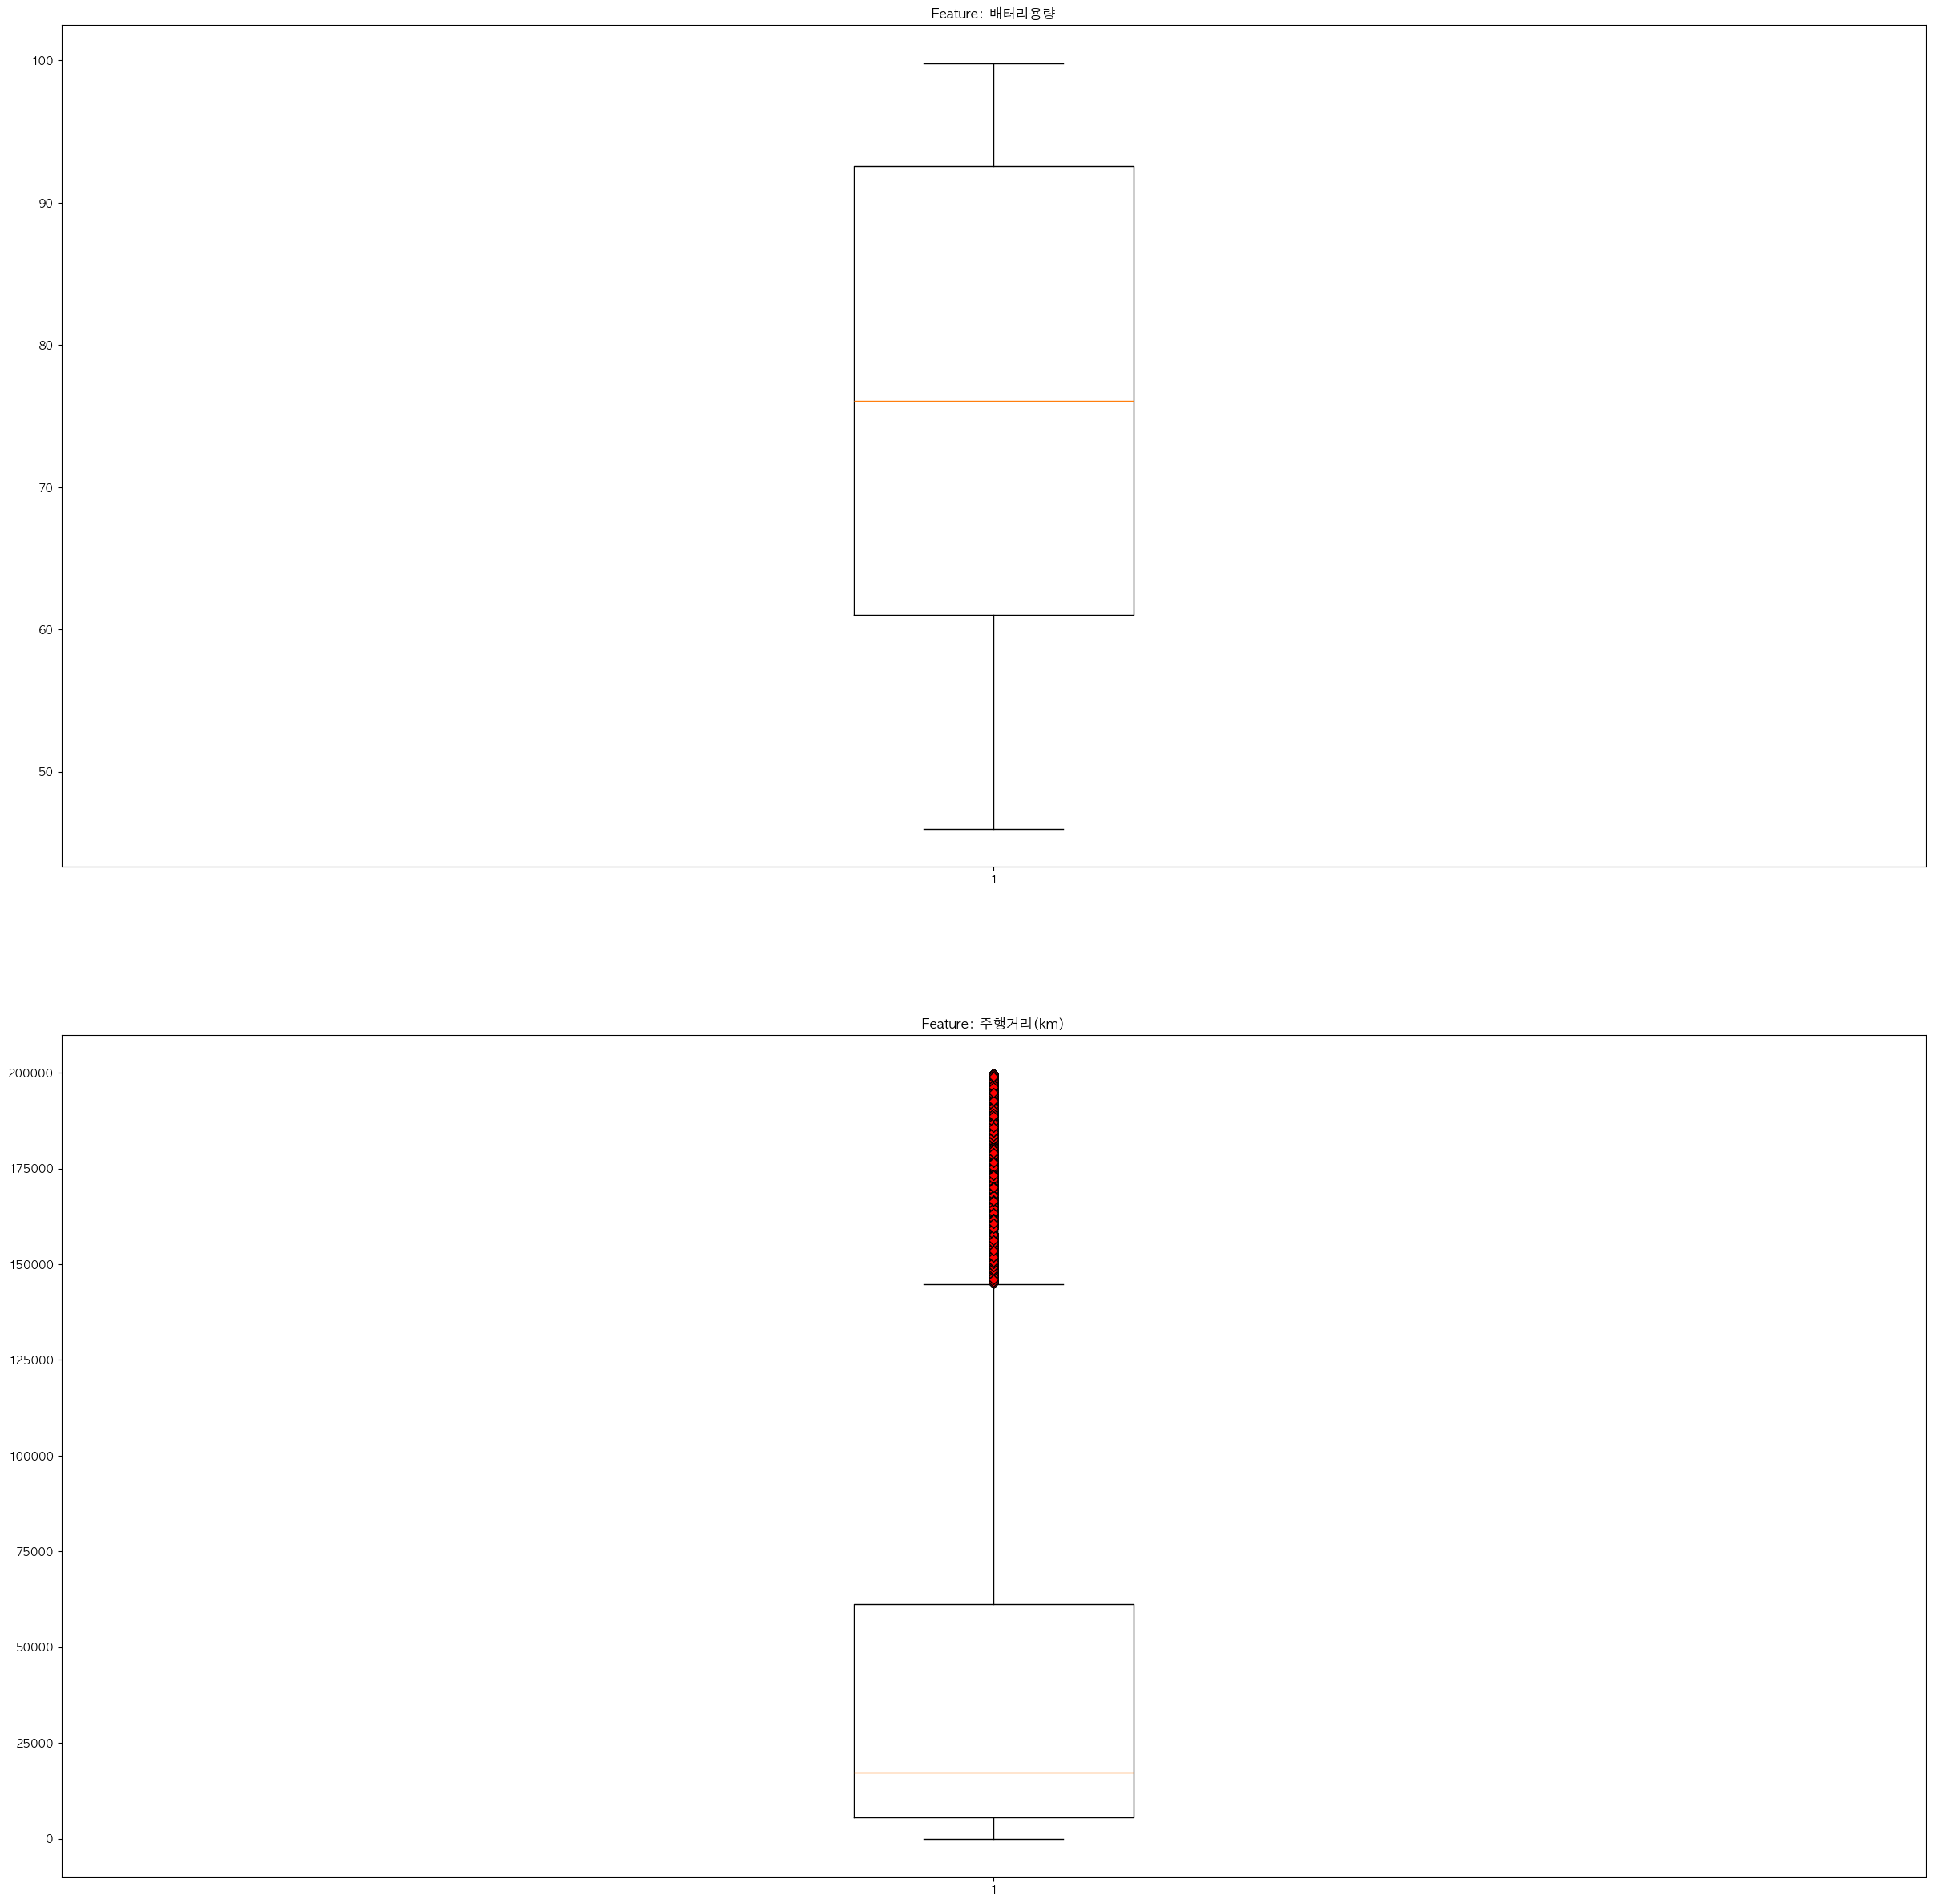

In [14]:
numeric_cols = ['배터리용량', '주행거리(km)']
plt.figure(figsize=(30, 30))
col_idx = 0
for col in numeric_cols:
    col_idx += 1
    plt.subplot(2, 1, col_idx)
    plt.boxplot(train_raw[[col]], flierprops= dict(markerfacecolor = 'r', marker = 'D'))
    plt.title(f'Feature: {col}')

In [16]:
train_raw.groupby('차량상태').describe()[['주행거리(km)']].T

차량상태              Brand New    Nearly New      Pre-Owned
주행거리(km) count  3380.000000   2059.000000    2058.000000
         mean   4935.953550  30602.352113  122610.892128
         std    2897.745303  12257.976737   45517.411096
         min       3.000000  10004.000000   11477.000000
         25%    2372.750000  20499.000000   82717.000000
         50%    4980.000000  30453.000000  123352.500000
         75%    7440.750000  40270.000000  161763.500000
         max    9999.000000  79226.000000  199827.000000

In [47]:
# bin = [0, 5000, 10000, 30000, 80000, 120000, float('inf')]
# label = ['5000km 이하', '10000km 이하', '30000km 이하', '80000km 이하', '120000km 이하', '120000km 초과']

# train_raw['주행거리구간별'] = pd.cut(train_raw['주행거리(km)'], bins = bin, labels = label)
# train_raw

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년),가격(백만원),주행거리구간별
0,TRAIN_0000,P사,TayGTS,Nearly New,86.077,AWD,13642,0,No,2,159.66,30000km 이하
1,TRAIN_0001,K사,Niro,Nearly New,56.000,FWD,10199,6,No,0,28.01,30000km 이하
2,TRAIN_0002,A사,eT,Brand New,91.200,AWD,2361,7,No,0,66.27,5000km 이하
3,TRAIN_0003,A사,RSeTGT,Nearly New,NaN,AWD,21683,3,No,0,99.16,30000km 이하
4,TRAIN_0004,B사,i5,Pre-Owned,61.018,AWD,178205,1,No,0,62.02,120000km 초과
...,...,...,...,...,...,...,...,...,...,...,...,...
7492,TRAIN_7492,H사,ION5,Brand New,NaN,AWD,3773,10,No,0,35.95,5000km 이하
7493,TRAIN_7493,B사,i3,Pre-Owned,46.000,RWD,135411,2,No,0,23.40,120000km 초과
7494,TRAIN_7494,P사,TayCT,Brand New,NaN,AWD,1363,2,No,0,120.00,5000km 이하
7495,TRAIN_7495,B사,i3,Nearly New,56.000,RWD,39445,6,No,2,24.00,80000km 이하


In [17]:
train_raw.isna().sum()

ID          0
제조사         0
모델          0
차량상태        0
배터리용량       0
구동방식        0
주행거리(km)    0
보증기간(년)     0
사고이력        0
연식(년)       0
가격(백만원)     0
dtype: int64

In [46]:
test_raw['배터리용량'] = test_raw['배터리용량'].fillna(
    train_raw.groupby('차량상태')['배터리용량'].transform('mean')
    )
test_raw

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년)
0,TEST_000,P사,TayCT,Nearly New,76.093000,AWD,14057,2,No,0
1,TEST_001,B사,iX,Brand New,90.000000,AWD,7547,8,No,0
2,TEST_002,B사,i5,Brand New,92.586567,RWD,7197,7,Yes,0
3,TEST_003,H사,ION5,Nearly New,68.479000,AWD,10357,7,No,1
4,TEST_004,K사,EV6,Brand New,59.053240,FWD,7597,10,No,0
...,...,...,...,...,...,...,...,...,...,...
841,TEST_841,P사,TayGTS,Pre-Owned,64.683000,AWD,117298,2,No,0
842,TEST_842,V사,ID4,Pre-Owned,55.547000,AWD,72308,0,No,0
843,TEST_843,V사,ID4,Pre-Owned,55.547000,AWD,124537,0,No,0
844,TEST_844,A사,Q4eT,Nearly New,69.646000,AWD,15629,4,No,0


In [21]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7497 entries, 0 to 7496
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7497 non-null   object 
 1   제조사       7497 non-null   object 
 2   모델        7497 non-null   object 
 3   차량상태      7497 non-null   object 
 4   배터리용량     7497 non-null   float64
 5   구동방식      7497 non-null   object 
 6   주행거리(km)  7497 non-null   int64  
 7   보증기간(년)   7497 non-null   int64  
 8   사고이력      7497 non-null   object 
 9   연식(년)     7497 non-null   int64  
 10  가격(백만원)   7497 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 644.4+ KB


In [22]:
test_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        846 non-null    object 
 1   제조사       846 non-null    object 
 2   모델        846 non-null    object 
 3   차량상태      846 non-null    object 
 4   배터리용량     846 non-null    float64
 5   구동방식      846 non-null    object 
 6   주행거리(km)  846 non-null    int64  
 7   보증기간(년)   846 non-null    int64  
 8   사고이력      846 non-null    object 
 9   연식(년)     846 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 66.2+ KB


In [23]:
test_raw.isna().sum()

ID          0
제조사         0
모델          0
차량상태        0
배터리용량       0
구동방식        0
주행거리(km)    0
보증기간(년)     0
사고이력        0
연식(년)       0
dtype: int64

In [24]:
train = train_raw.drop(['차량상태'], axis=1)
test = test_raw.drop(['차량상태'], axis=1)

In [25]:
x_train = train.drop(['ID', '가격(백만원)'], axis = 1)
y_train = train['가격(백만원)']

x_test = test.drop(['ID'], axis = 1)

In [26]:
x_train

,모델,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년)
0,TayGTS,86.077000,AWD,13642,0,No,2
1,Niro,56.000000,FWD,10199,6,No,0
2,eT,91.200000,AWD,2361,7,No,0
3,RSeTGT,66.678888,AWD,21683,3,No,0
4,i5,61.018000,AWD,178205,1,No,0
...,...,...,...,...,...,...,...
7492,ION5,92.586567,AWD,3773,10,No,0
7493,i3,46.000000,RWD,135411,2,No,0
7494,TayCT,92.586567,AWD,1363,2,No,0
7495,i3,56.000000,RWD,39445,6,No,2


In [27]:
y_train

0       159.66
1        28.01
2        66.27
3        99.16
4        62.02
         ...  
7492     35.95
7493     23.40
7494    120.00
7495     24.00
7496     74.06
Name: 가격(백만원), Length: 7497, dtype: float64

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

categorical_features = ['제조사', '모델', '구동방식', '사고이력']

for i in categorical_features:
    le = LabelEncoder()
    le=le.fit(x_train[i]) 
    x_train[i]=le.transform(x_train[i])
    
    for case in np.unique(x_test[i]):
        if case not in le.classes_: 
            le.classes_ = np.append(le.classes_, case) 
    x_test[i]=le.transform(x_test[i])
    
display(x_train.head())

,모델,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년)
0,16,86.077000,0,13642,0,0,2
1,10,56.000000,1,10199,6,0,0
2,17,91.200000,0,2361,7,0,0
3,12,66.678888,0,21683,3,0,0
4,19,61.018000,0,178205,1,0,0


In [35]:
x_test.isna().sum()

모델          0
배터리용량       0
구동방식        0
주행거리(km)    0
보증기간(년)     0
사고이력        0
연식(년)       0
dtype: int64

In [29]:
# xgboost
import xgboost as xgb

xgb_regressor = xgb.XGBRegressor(
    random_state = 50, 
    learning_rate = 0.1,
    max_depth = 5
    )

In [30]:
xgb_regressor.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=50, ...)

In [31]:
xgb_regressor.score(x_train, y_train)

0.9987642753323299

In [ ]:
y_test = xgb_regressor.predict(x_test)

In [33]:
submission['가격(백만원)'] = y_test
submission.head()

,ID,가격(백만원)
0,TEST_000,129.122223
1,TEST_001,80.209244
2,TEST_002,64.320053
3,TEST_003,35.002636
4,TEST_004,47.848282


In [34]:
submission.to_csv('./my_submission.csv',index=False)